In [ ]:

#install requirements if needed
%pwd
!python -m pip install -U openml scikit-learn pandas
!python -m pip install -r ../requirements.txt

In [22]:
# import libraries and set seed
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [23]:
# load dataset from OpenML dataset (ID:1488 for parkinsons)
import openml

DATASET_ID = 1488
dataset = openml.datasets.get_dataset(DATASET_ID)

X, y, categorical_indicator, attribute_names = dataset.get_data(
    target=dataset.default_target_attribute
)

print("Target column:", dataset.default_target_attribute)
print("X shape:", X.shape, "y shape:", y.shape)
print("Columns:", list(X.columns)[:10], "...")
print("y distribution:\n", pd.Series(y).value_counts(dropna=False))

Target column: Class
X shape: (195, 22) y shape: (195,)
Columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10'] ...
y distribution:
 Class
2    147
1     48
Name: count, dtype: int64


In [24]:
X = X.copy()

# find if any str type data in the features and drop them (since we are only doing numeric models for now)
non_numeric_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
if len(non_numeric_cols) > 0:
    print("Dropping non-numeric columns:", non_numeric_cols)
    X.drop(columns=non_numeric_cols, inplace=True)

print("X shape:", X.shape)
print("X dtypes summary:\n", X.dtypes.value_counts())
print("Any missing in X?", X.isna().any().any())

X shape: (195, 22)
X dtypes summary:
 float64    22
Name: count, dtype: int64
Any missing in X? False


In [25]:
# change class: {1,2} to {0,1}, in Description, the PD class is 1 and the healthy class is 2, so we will map 1 to 0 and 2 to 1 for binary classification
y_raw = pd.Series(y).astype(int)

print("Original y values:", sorted(y_raw.unique()))
print("Original y distribution:\n", y_raw.value_counts())

classes_sorted = sorted(y_raw.unique())
mapping = {classes_sorted[0]: 0, classes_sorted[1]: 1}

y_clean = y_raw.map(mapping).astype(int)

print("\nMapping used:", mapping)
print("Binary y distribution:\n", y_clean.value_counts())

Original y values: [np.int64(1), np.int64(2)]
Original y distribution:
 Class
2    147
1     48
Name: count, dtype: int64

Mapping used: {np.int64(1): 0, np.int64(2): 1}
Binary y distribution:
 Class
1    147
0     48
Name: count, dtype: int64


In [26]:
# split into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean,
    test_size=0.2,
    stratify=y_clean,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train y distribution:\n", pd.Series(y_train).value_counts(normalize=True))
print("Test y distribution:\n", pd.Series(y_test).value_counts(normalize=True))

Train: (156, 22) Test: (39, 22)
Train y distribution:
 Class
1    0.75641
0    0.24359
Name: proportion, dtype: float64
Test y distribution:
 Class
1    0.74359
0    0.25641
Name: proportion, dtype: float64


In [27]:
# KFold cross-validation setup and pipelines for numeric preprocessing
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

numeric_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# for models that don't require scaling, we can use a simpler pipeline (Tree models)
no_scale_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

In [28]:
# define models with their corresponding preprocessing steps
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

models = {
    "LogisticRegression": ("scale", LogisticRegression(max_iter=8000, class_weight="balanced", random_state=RANDOM_STATE)),
    "SVM_RBF": ("scale", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE)),
    "KNN": ("scale", KNeighborsClassifier()),
    "MLP": ("scale", MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=3000, random_state=RANDOM_STATE)),
    "RandomForest": ("noscale", RandomForestClassifier(n_estimators=600, random_state=RANDOM_STATE, class_weight="balanced")),
    "GradientBoosting": ("noscale", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    "HistGradientBoosting": ("noscale", HistGradientBoostingClassifier(random_state=RANDOM_STATE))
}

In [29]:
# run cross-validation for all models and collect results in a summary table
from sklearn.model_selection import cross_validate

def cv_summary_table(cv_results_dict):
    rows = []
    for model_name, res in cv_results_dict.items():
        row = {"model": model_name}
        for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
            row[f"{k}_mean"] = np.mean(res[f"test_{k}"])
            row[f"{k}_std"] = np.std(res[f"test_{k}"])
        rows.append(row)
    df = pd.DataFrame(rows).sort_values("roc_auc_mean", ascending=False)
    return df

cv_results_all = {}

for name, (prep_type, clf) in models.items():
    preprocess = numeric_preprocess if prep_type == "scale" else no_scale_preprocess
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", clf)])
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    cv_results_all[name] = res
    print(f"Done CV: {name}")

cv_table = cv_summary_table(cv_results_all)
cv_table

Done CV: LogisticRegression
Done CV: SVM_RBF
Done CV: KNN
Done CV: MLP
Done CV: RandomForest
Done CV: GradientBoosting
Done CV: HistGradientBoosting


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
3,MLP,0.903831,0.049989,0.934629,0.038861,0.940942,0.050382,0.936786,0.033309,0.964325,0.026484
6,HistGradientBoosting,0.891129,0.043429,0.907429,0.050519,0.957609,0.026367,0.930851,0.026864,0.958417,0.032518
5,GradientBoosting,0.871976,0.027776,0.898896,0.042496,0.940580,0.051475,0.917232,0.018763,0.949198,0.027183
4,RandomForest,0.891129,0.052139,0.910169,0.031380,0.948551,0.042757,0.928821,0.035552,0.945743,0.021301
2,KNN,0.871976,0.053410,0.894192,0.060193,0.948551,0.050225,0.918549,0.034922,0.936921,0.034414
1,SVM_RBF,0.782056,0.062469,0.937310,0.038175,0.763406,0.055230,0.840934,0.045780,0.909407,0.040177
0,LogisticRegression,0.814113,0.031452,0.943247,0.034634,0.805072,0.043968,0.867347,0.022745,0.900401,0.044218


In [ ]:
# fit all models on the full training set
fitted_models = {}

for name, (prep_type, clf) in models.items():
    preprocess = numeric_preprocess if prep_type == "scale" else no_scale_preprocess
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", clf)])
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe

print(fitted_models.keys())

dict_keys(['LogisticRegression', 'SVM_RBF', 'KNN', 'MLP', 'RandomForest', 'GradientBoosting', 'HistGradientBoosting'])


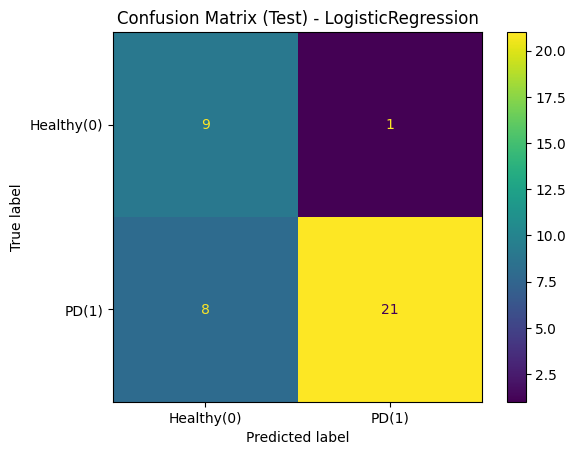

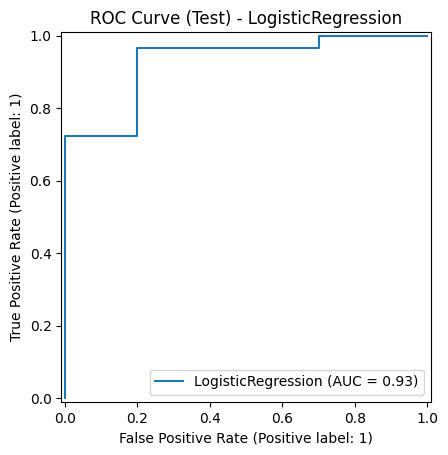

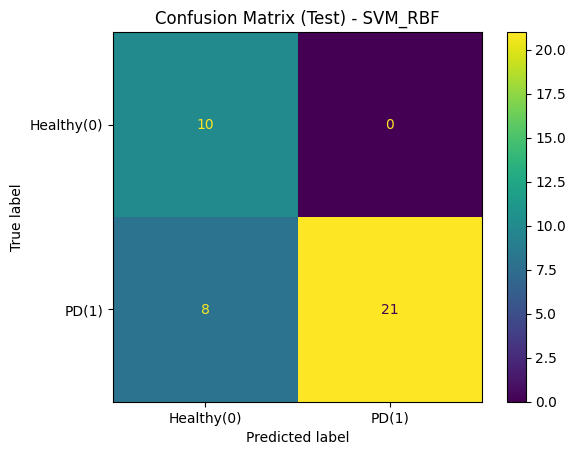

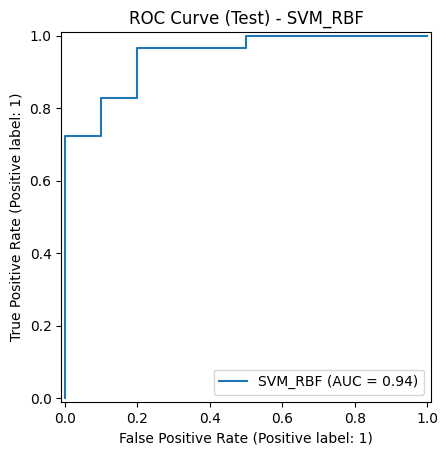

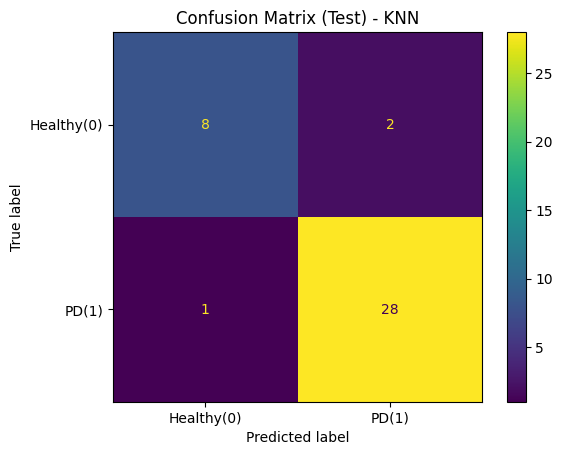

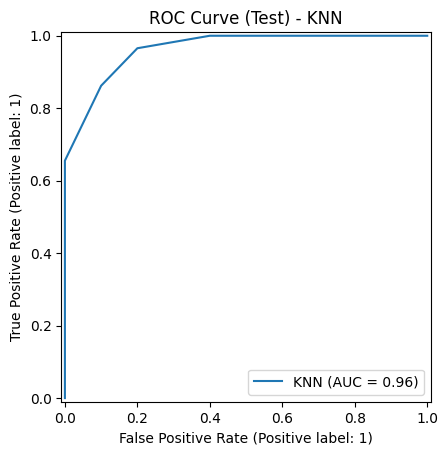

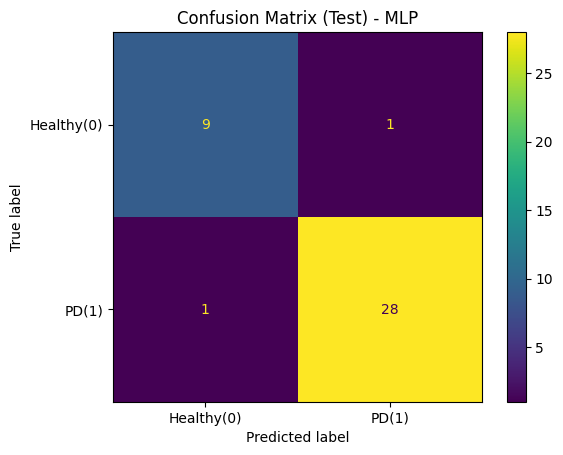

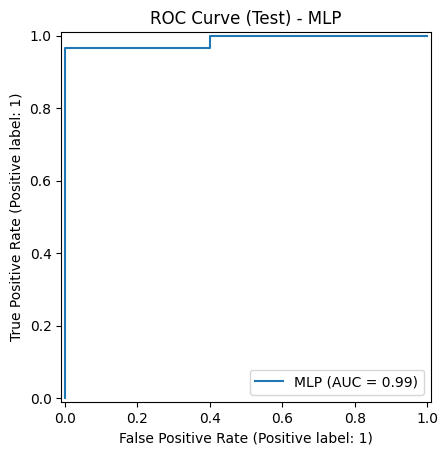

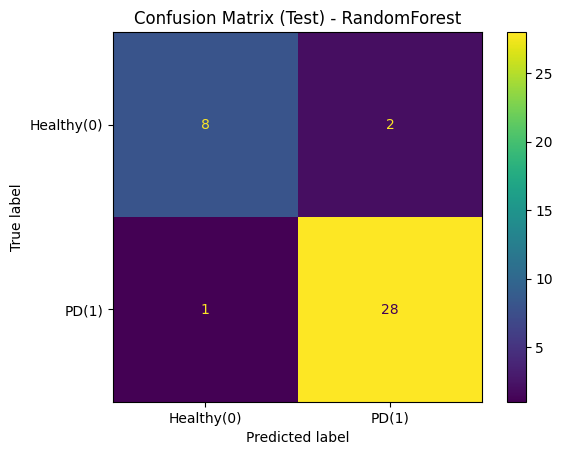

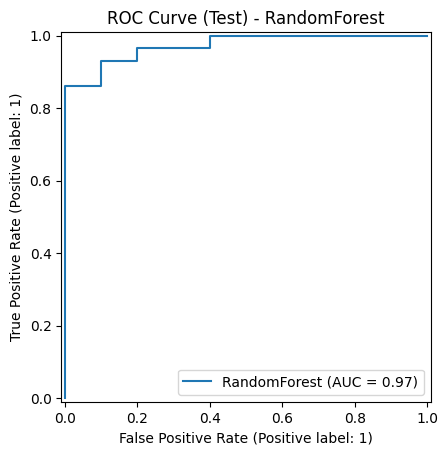

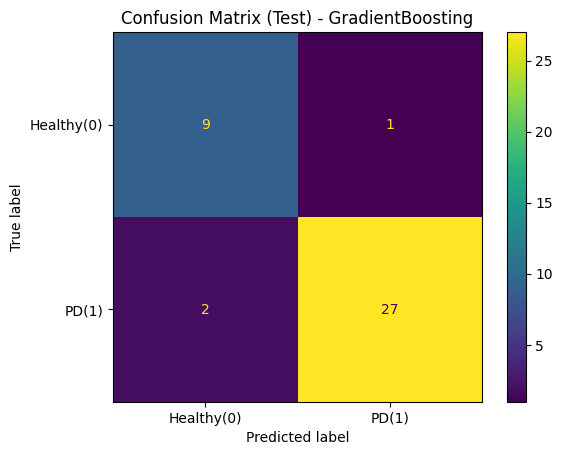

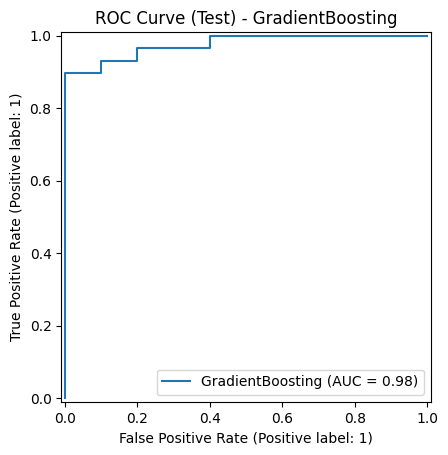

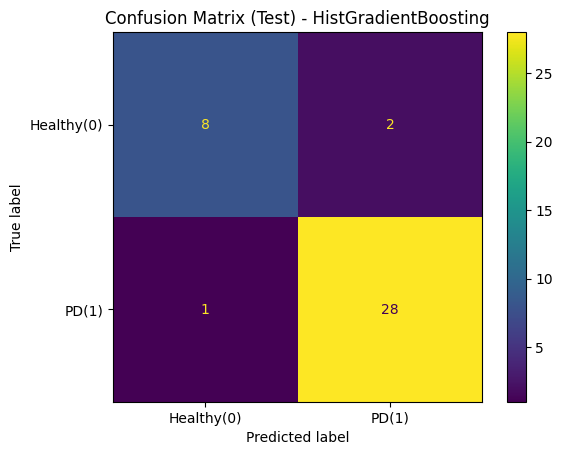

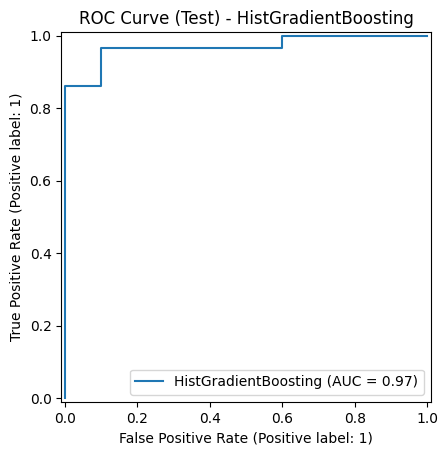

In [ ]:
# fit each model on the full training set and evaluate on the test set, including confusion matrix and ROC curve
for name, pipe in fitted_models.items():
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy(0)", "PD(1)"])
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix (Test) - {name}")
    plt.show()

    # ROC Curve
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name)
    plt.title(f"ROC Curve (Test) - {name}")
    plt.show()

The result for MLP is the best, let's use MLP for this dataset

In [32]:
# set MLP parameters pipeline
mlp_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        max_iter=3000,
        random_state=RANDOM_STATE
    ))
])

cross-validation scores

In [33]:
# cross-validate MLP with the same cv and scoring (The cross-validation scores)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv_results = cross_validate(
    mlp_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)


cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean(),
    ],
    "Std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std(),
    ]
})

cv_summary

,Metric,Mean,Std
0,Accuracy,0.903831,0.049989
1,Precision,0.934629,0.038861
2,Recall,0.940942,0.050382
3,F1,0.936786,0.033309
4,ROC-AUC,0.964325,0.026484


In [34]:
mlp_pipeline.fit(X_train, y_train)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


Accuracy, Precision, Recall, F1-Score

In [35]:
# test set evaluation
y_pred = mlp_pipeline.predict(X_test)
y_prob = mlp_pipeline.predict_proba(X_test)[:, 1]

test_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

pd.DataFrame(test_metrics, index=["Test Set"])

,Accuracy,Precision,Recall,F1,ROC-AUC
Test Set,0.948718,0.965517,0.965517,0.965517,0.986207


Confusion Matrix

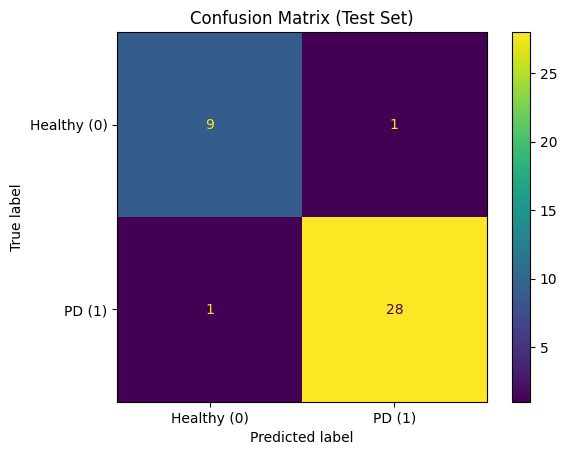

In [36]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Healthy (0)", "PD (1)"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix (Test Set)")
plt.show()

ROC Curve

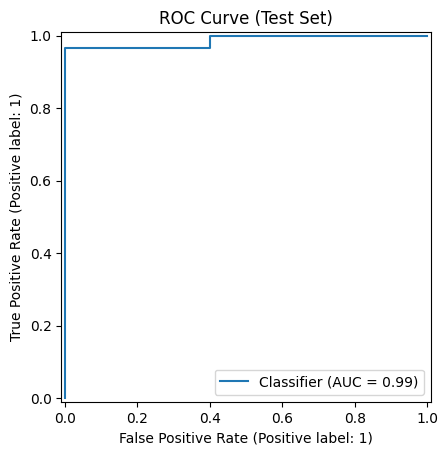

In [37]:
# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve (Test Set)")
plt.show()